In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
import flows.shear as shear
from models import *
from models.FENE import *

In [5]:
ndim = 3  # Spatial dimensions

## Steady Shear

In [6]:
Wimax = 1e3  # Maximum Weissenberg number
models = [
    Oldroyd_B.Oldroyd_B,
    Oldroyd_A.Oldroyd_A,
    FENE_P.FENE_P,
    FENE_CR.FENE_CR,
    Giesekus.Giesekus,
]
model_parameters = [
    {"β":0.0},
    {"β":0.0},
    {"β":0.0, "L":10},
    {"β":0.0, "L":10},
    {"β":0.0, "α":0.5},
]

In [7]:
res_steady = []  # Result of every model requested
for idx, model in enumerate(models):
    Wi, τ = shear.steady(ndim, Wimax, model, model_parameters[idx])
    res_steady.append((Wi, τ))

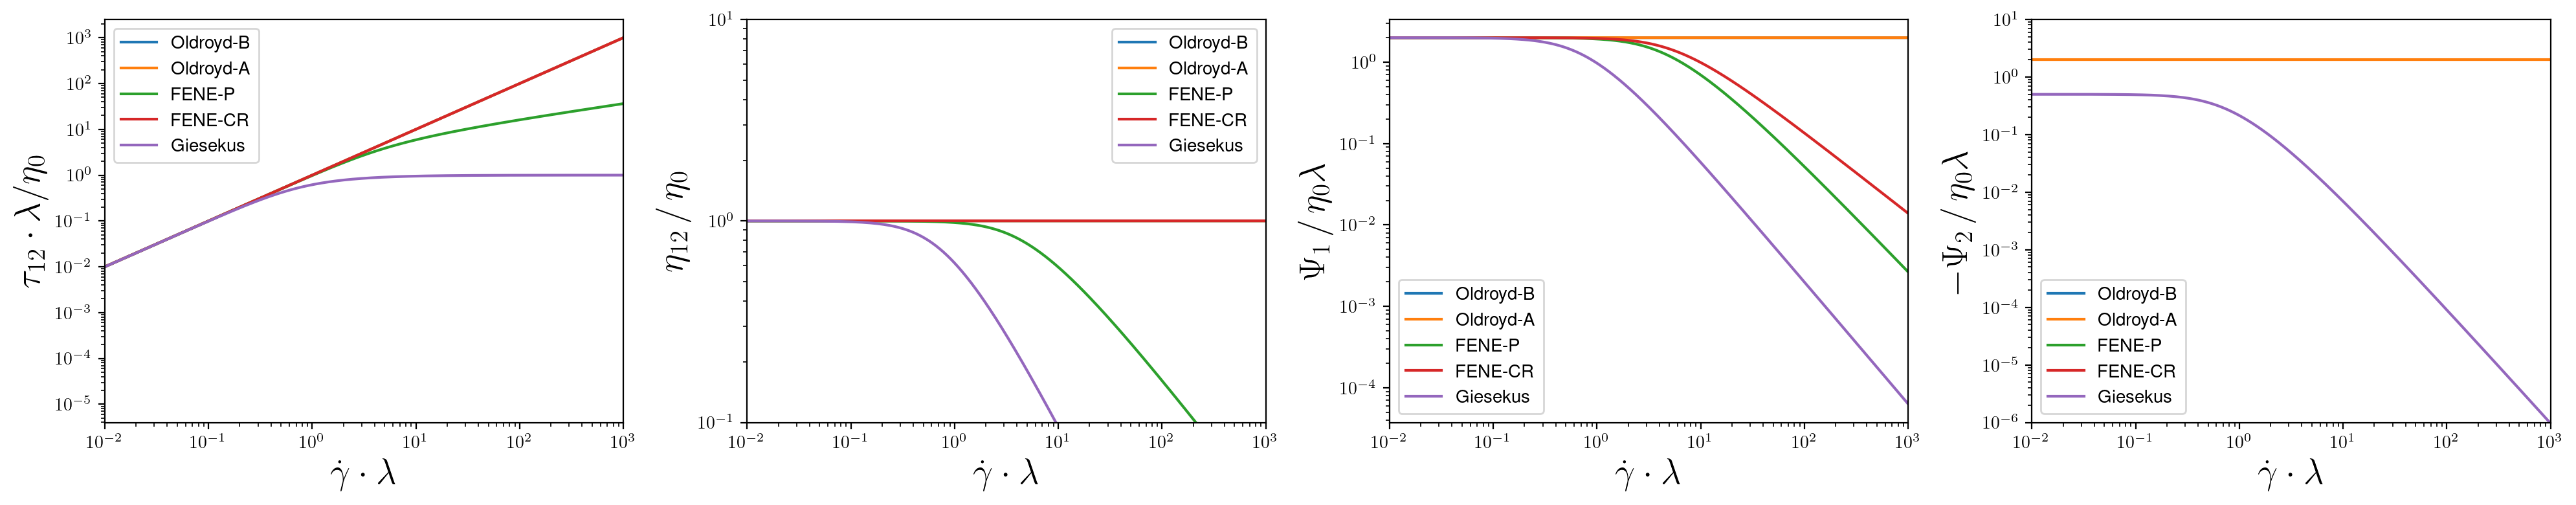

In [8]:
fig, axes = plt.subplots(1, ndim+1, figsize=(5*(ndim+1),4))
for idx, model in enumerate(models):
    Wi, τ = res_steady[idx]
    axes[0].plot(Wi, τ[:,0,1], label=model.name)
    axes[1].plot(Wi, τ[:,0,1]/Wi, label=model.name)
    axes[2].plot(Wi, (τ[:,0,0]-τ[:,1,1])/Wi**2, label=model.name)
    if ndim > 2:
        axes[3].plot(Wi, -(τ[:,1,1]-τ[:,2,2])/Wi**2, label=model.name)

axes[0].set_ylabel("$\\tau_{12} \\cdot \\lambda / \\eta_0$", size=20)
axes[1].set_ylabel("$\\eta_{12} \\,/\\, \\eta_0$", size=20)
axes[2].set_ylabel("$\\Psi_1 \\,/\\, \\eta_0 \\lambda$", size=20)
if ndim > 2:
    axes[3].set_ylabel("$-\\Psi_2 \\,/\\, \\eta_0 \\lambda$", size=20)
for ax in axes:
    ax.set_xlabel("$\\dot{{\\gamma}} \\cdot \\lambda$", size=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([1e-2,Wimax])
    ax.legend()
axes[1].set_ylim([1e-1,1e1])
if ndim > 2:
    axes[3].set_ylim([1e-6,1e1])
plt.tight_layout()
plt.show()

## Shear Startup

In [9]:
Wi_startup = 30.0
models = [
    Oldroyd_B.Oldroyd_B,
    Oldroyd_A.Oldroyd_A,
    FENE_CR.FENE_CR,
    FENE_P.FENE_P,
    Johnson_Segalman.Johnson_Segalman,
    Giesekus.Giesekus,
    FENE_P_Multimode.FENE_P_Multimode(2)
]
model_parameters = [
    {"β":0.0},
    {"β":0.0},
    {"β":0.0, "L":100},
    {"β":0.0, "L":100},
    {"β":0.0, "ε0":0.2},
    {"β":0.0, "α":0.9},
    {"β":[0.5, 0.5], "L": [100, 50], "λfrac": [1.0, 0.5]}
]

In [10]:
from scipy.integrate import RK45, Radau, LSODA

res_startup = []  # Result of every model requested
for idx, model in enumerate(models):
    t, τ = shear.startup(ndim, Wi_startup, model, model_parameters[idx], ODESolver=LSODA)
    res_startup.append((t, τ))

/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:102: RuntimeWarning: Ended due to solver status=finished
  warnings.warn(f"Ended due to solver status={sol.status}",


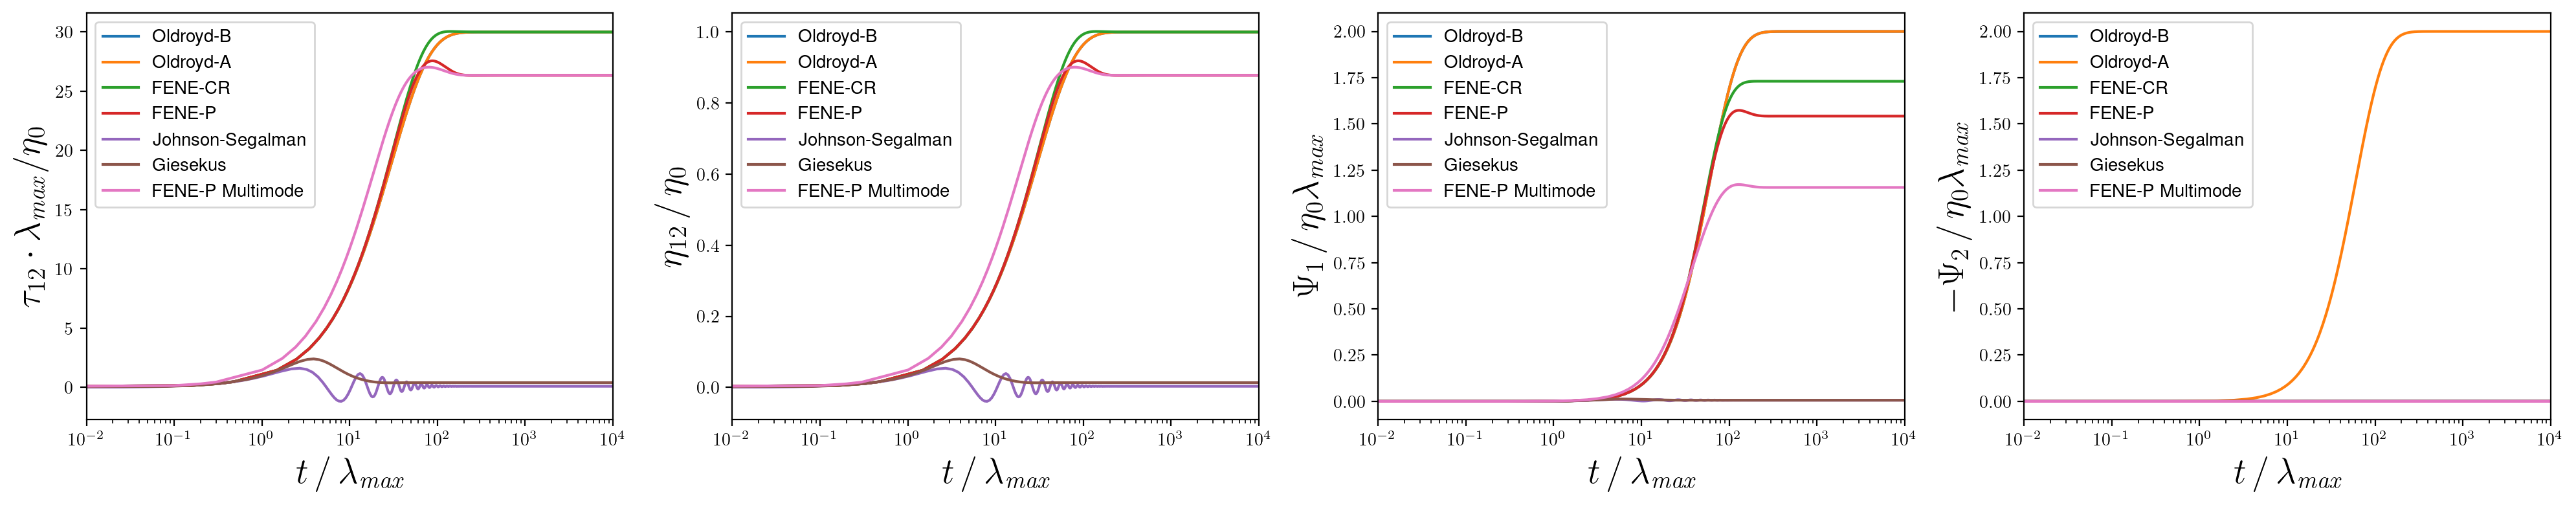

In [11]:
fig, axes = plt.subplots(1, ndim+1, figsize=(5*(ndim+1),4))

for idx, model in enumerate(models):
    t, τ = res_startup[idx]
    axes[0].plot(t, τ[:,0,1], label=model.name)
    axes[1].plot(t, τ[:,0,1]/Wi_startup, label=model.name)
    axes[2].plot(t, (τ[:,0,0]-τ[:,1,1])/Wi_startup**2, label=model.name)
    if ndim > 2:
        axes[3].plot(t, -(τ[:,1,1]-τ[:,2,2])/Wi_startup**2, label=model.name)

axes[0].set_ylabel("$\\tau_{12} \\cdot \\lambda_\\mathit{max} / \\eta_0$", size=20)
axes[1].set_ylabel("$\\eta_{12} \\,/\\, \\eta_0$", size=20)
axes[2].set_ylabel("$\\Psi_1 \\,/\\, \\eta_0 \\lambda_\\mathit{max}$", size=20)
if ndim > 2:
    axes[3].set_ylabel("$-\\Psi_2 \\,/\\, \\eta_0 \\lambda_\\mathit{max}$", size=20)
for ax in axes:
    ax.set_xlabel("$t \\,/\\, \\lambda_\\mathit{max}$", size=20)
    ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlim([1e-2,1e4])
    ax.legend()
plt.tight_layout()
plt.show()

## Relaxation (Step Strain)

In [12]:
γ, dt = 5, 0.1
models = [
    Oldroyd_B.Oldroyd_B,
    Oldroyd_A.Oldroyd_A,
    FENE_CR.FENE_CR,
    FENE_P.FENE_P,
    Johnson_Segalman.Johnson_Segalman,
    Giesekus.Giesekus,
    FENE_P_Multimode.FENE_P_Multimode(2),
    CoupledUCM.CoupledUCM,
    FENE_P_Multimode.FENE_P_Multimode(10),
]
model_parameters = [
    {"β":0.0},
    {"β":0.0},
    {"β":0.0, "L":100},
    {"β":0.0, "L":100},
    {"β":0.0, "ε0":0.2},
    {"β":0.0, "α":0.9},
    {"β":[0.2, 0.8], "L": [100, 50], "λfrac": [1.0, 0.5]},
    {"λ":2.0, "β1":0.2, "θ":0.1},
    {"β":[2**-n for n in range(1,11)], "L": [1000 for n in range(1,11)], "λfrac": [0.5**-n for n in range(1,11)]},
]

In [13]:
from scipy.integrate import RK45, Radau, LSODA

res_stepstrain = []  # Result of every model requested
for idx, model in enumerate(models):
    t, τ = shear.relaxation(ndim, γ, dt, model, model_parameters[idx], ODESolver=LSODA)
    res_stepstrain.append((t, τ))

/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:170: RuntimeWarning: Ended due to solver status=finished
  warnings.warn(f"Ended due to solver status={sol.status}",


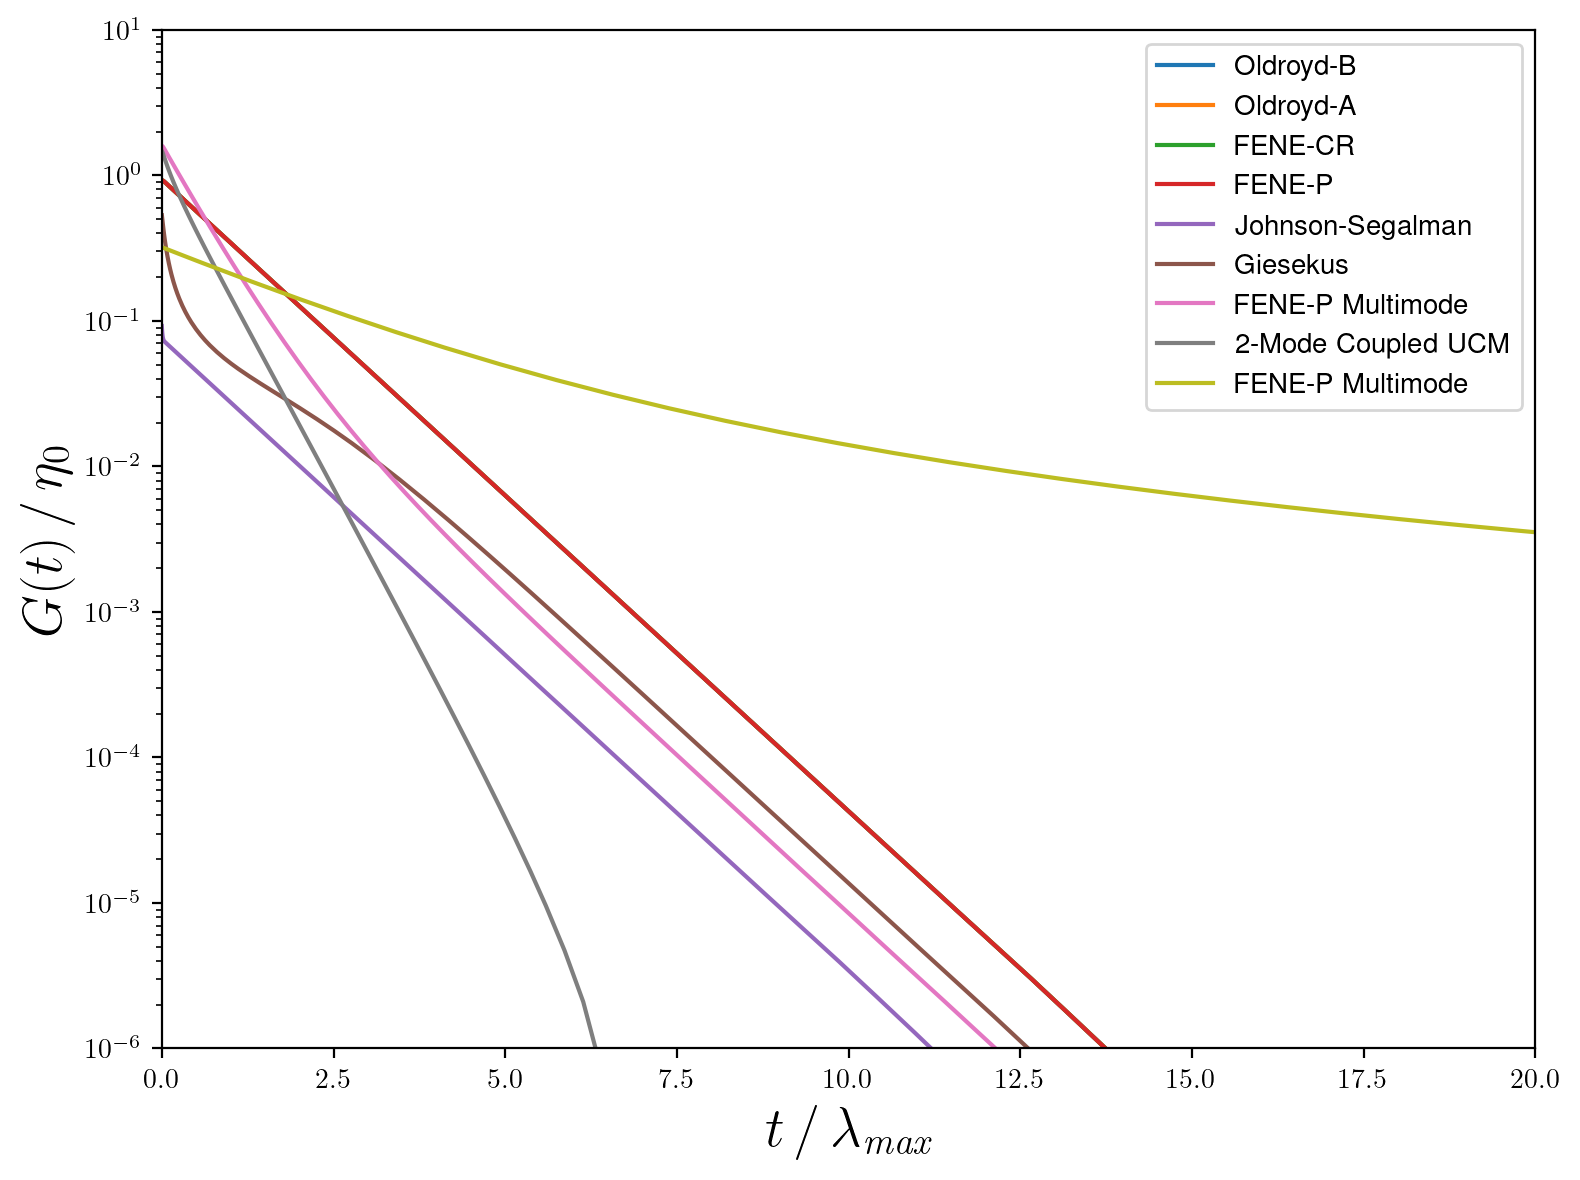

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

for idx, model in enumerate(models):
    t, τ = res_stepstrain[idx]
    ax.plot(t-dt, τ[:,0,1]/γ, label=model.name)

ax.set_ylabel("$G(t) \\,/\\, \\eta_0$", size=20)
ax.set_xlabel("$t \\,/\\, \\lambda_\\mathit{max}$", size=20)
ax.set_yscale("log")
ax.set_xlim([0, 20])
ax.set_ylim([1e-6, 10])
ax.legend()
plt.tight_layout()
plt.show()

# Cessation

In [15]:
dγ0s = [1, 10, 100, 1000]
models = [
    Oldroyd_B.Oldroyd_B,
    FENE_CR.FENE_CR,
    Giesekus.Giesekus,
    FENE_P_Multimode.FENE_P_Multimode(10),
]
model_parameters = [
    {"β":0.0},
    {"β":0.0, "L":100},
    {"β":0.0, "α":0.2},
    {"β":[2**-n for n in range(1,11)], "L": [1000 for n in range(1,11)], "λfrac": [0.5**-n for n in range(1,11)]},
]

In [16]:
from scipy.integrate import RK45, Radau, LSODA

res_cessation = []  # Result of every model requested
for idx, model in enumerate(models):
    for _, dγ0 in enumerate(dγ0s):
        t, τ = shear.cessation(ndim, dγ0, model, model_parameters[idx], ODESolver=LSODA)
        res_cessation.append((t, τ))

/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:264: RuntimeWarning: Ended due to solver status=finished
  warnings.warn(f"Ended due to solver status={sol.status}",
/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:225: RuntimeWarning: Failed to find initial state for dγ0=100 and FENE-CR. Trying to decrease dγ0.
  warnings.warn(f"Failed to find initial state for dγ0={dγ0} and {constEq.name}. Trying to decrease dγ0.",
/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:225: RuntimeWarning: Failed to find initial state for dγ0=1000 and FENE-CR. Trying to decrease dγ0.
  warnings.warn(f"Failed to find initial state for dγ0={dγ0} and {constEq.name}. Trying to decrease dγ0.",
/Users/fabianhillebrand/Documents/OIST/Thesis/02-Simulations/04-ConstitutiveModels/flows/shear.py:225: RuntimeWarning: Failed to find initial state for dγ0=100 and Giesekus. Tr

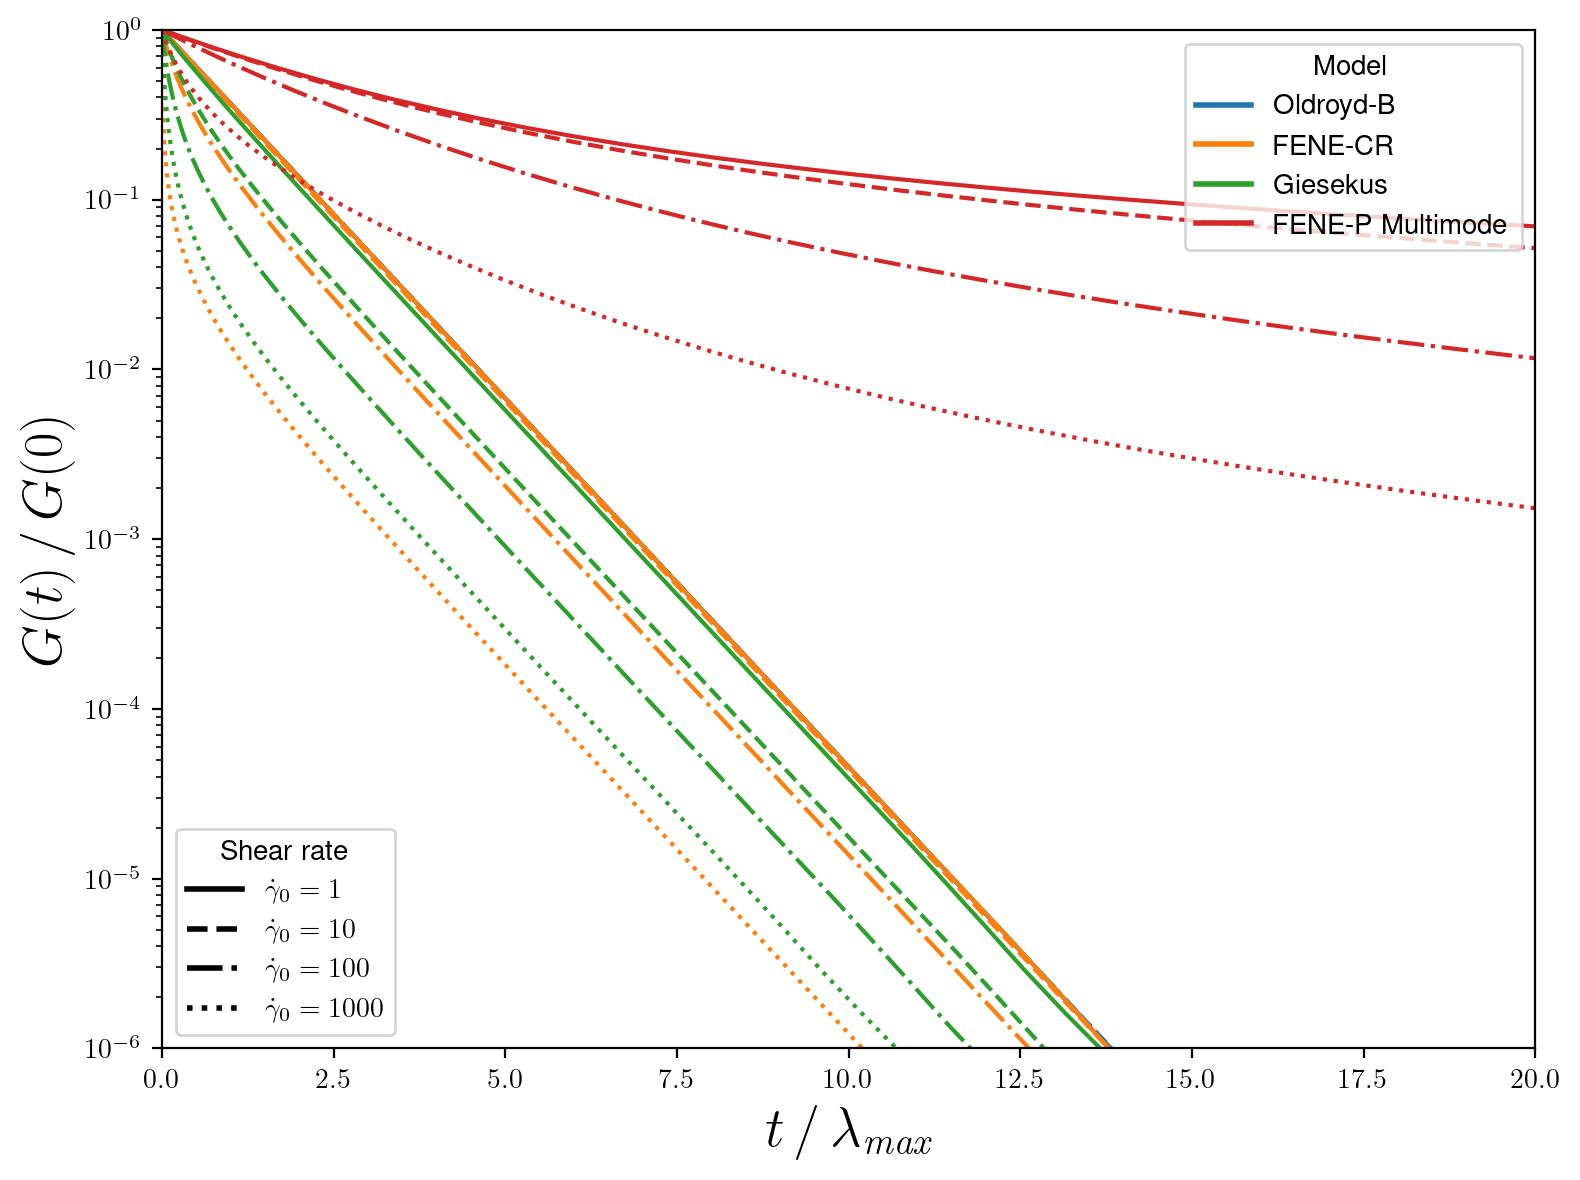

In [17]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(8,6))

colors = plt.cm.tab10.colors[:len(models)]
linestyles = ['-', '--', '-.', ':']

for idx, model in enumerate(models):
    for jdx, dγ0 in enumerate(dγ0s):
        t, τ = res_cessation[idx * len(dγ0s) + jdx]
        ax.plot(t, τ[:,0,1]/τ[0,0,1], color=colors[idx], linestyle=linestyles[jdx])

model_handles = [
    Line2D([0], [0], color=colors[idx], lw=2, label=model.name)
    for idx, model in enumerate(models)
]
shear_handles = [
    Line2D([0], [0], color='k', lw=2,
           linestyle=linestyles[jdx],
           label=f"$\\dot{{\\gamma}}_0={dγ0}$")
    for jdx, dγ0 in enumerate(dγ0s)
]

legend1 = ax.legend(handles=model_handles, title="Model", loc="upper right")
ax.add_artist(legend1)
ax.legend(handles=shear_handles, title="Shear rate", loc="lower left")

ax.set_ylabel("$G(t) \\,/\\, G(0)$", size=20)
ax.set_xlabel("$t \\,/\\, \\lambda_\\mathit{max}$", size=20)
ax.set_yscale("log")
ax.set_xlim([0, 20])
ax.set_ylim([1e-6, 1])
plt.tight_layout()
plt.show()